# Notebook 14 | From Sample to Statistics

In [1]:
from foundations_of_probability_and_statistics.cars.horsepower_moments import conditional_horsepower_mean
from foundations_of_probability_and_statistics.cars.horsepower_moments import conditional_horsepower_variance
from foundations_of_probability_and_statistics.cars.sample_from_car_distribution import sample_from_car_distribution

import pandas as pd

# show all rows of data frames and series per default
pd.set_option("display.max_rows", None)

## One sample, honestly summarized

We drew one sample -- how do we summarize what it says, and how do we show it honestly? Fix the 200,000-car sample of notebook 10 at `random_state=42` and write $X = (H \mid B = b)$ per brand, with $\mu_b = \mathbb{E}[H \mid B = b]$ and $\sigma_b^2 = \mathrm{Var}(H \mid B = b)$ from the package. This notebook turns notebooks 10-13 into practice: per-brand size $n_b$, sample mean $\bar{X}_{n_b}^{(b)}$ against $\mu_b$, biased ($\hat{\sigma}^2$, `ddof=0`) vs. corrected ($s^2$, `ddof=1`) variance against $\sigma_b^2$, standard error $s / \sqrt{n_b}$, and one 95% normal-approximation interval $\bar{x} \pm 1.96 \, s / \sqrt{n_b}$ per brand. The CLT (notebook 13) justifies intervals for means -- never predictions of individual cars, whose distribution stays discrete.

## Derivation

1. Group the 200,000 draws by brand; each group is an iid sample from $p(H \mid B = b)$ with its own size $n_b$.
2. Estimate location with the sample mean $\bar{X}_{n_b}^{(b)}$ (notebook 10) and spread with $s^2$ (notebook 11, `ddof=1`).
3. Quantify the mean's own wiggle with the standard error $s / \sqrt{n_b}$: the $\sigma / \sqrt{n}$ of notebook 13 with $\sigma$ estimated.
4. Report $\bar{x} \pm 1.96 \, s / \sqrt{n_b}$ as the approximate 95% interval for $\mu_b$ -- honest about the center, silent about individuals.

The characteristic mistake is showing an interval for the mean as if it described the cars: with $n_b \approx 10^5$ the mean is pinned down to fractions of a horsepower while individual cars still scatter over hundreds.

## Worked example (by hand)

Same arithmetic every brand repeats, shown once for VW ($\mu = 150$, $\sigma^2 = 4500$ from notebooks 10-11):

$$\mathrm{SE} = \frac{s}{\sqrt{n_b}}, \qquad \text{95\% interval } \bar{x} \pm 1.96 \, \mathrm{SE}.$$

The code cell below evaluates this for all three brands and asserts each interval covers its exact $\mu_b$ -- the agreement check, not a hand-typed number. A sample standard deviation $s \approx 67$ over $n_b \approx 10^5$ cars gives $\mathrm{SE} \approx 0.2$ hp: the average is known two orders of magnitude better than any single car.

In [2]:
import math

import numpy as np

cars = sample_from_car_distribution(n_cars=200_000, random_state=42)

# per-brand summary: n_b, sample mean vs E[H | B = b], biased vs corrected variance
rows = {}
for brand in ["VW", "Porsche", "Ferrari"]:
    values = cars[cars["brand"] == brand]["horsepower"].to_numpy(dtype=float)
    mu = conditional_horsepower_mean(brand)
    var = conditional_horsepower_variance(brand)
    mean = float(values.mean())
    corrected = float(np.var(values, ddof=1))
    biased = float(np.var(values, ddof=0))
    se = float(np.sqrt(corrected / len(values)))
    assert math.isclose(mean, mu, rel_tol=0.02)
    assert math.isclose(corrected, var, rel_tol=0.05)
    assert math.isclose(biased, var * (len(values) - 1) / len(values), rel_tol=0.05)
    # 95% normal-approximation interval for the mean covers the exact mu_b
    assert mu >= mean - 1.96 * se and mu <= mean + 1.96 * se
    rows[brand] = {"n_b": len(values), "mean": mean, "s2": corrected, "se": se,
                   "ci_low": mean - 1.96 * se, "ci_high": mean + 1.96 * se,
                   "E[H | B = b]": mu, "Var(H | B = b)": var}
summary = pd.DataFrame(rows).T
summary

,n_b,mean,s2,se,ci_low,ci_high,E[H | B = b],Var(H | B = b)
VW,99972.0,150.150042,4489.779530,0.211921,149.734677,150.565407,150.0,4500.0
Porsche,60128.0,394.564928,11456.148128,0.436497,393.709395,395.420462,395.0,11475.0
Ferrari,39900.0,500.172932,5953.753396,0.386286,499.415812,500.930053,500.0,6000.0


## Generalization: three honest views of the same sample

Three figures over the same 200,000 cars, each answering a different question. (a) Grouped histograms of horsepower per brand (shared support bins, density normalization, dashed exact-mean vlines): what to see -- VW piles left, Ferrari centers, Porsche spreads widest; what it hides -- binning smooths the discreteness of the support. (b) Mean-with-interval panel (per-brand point, 95% whiskers, exact-mean markers): what to see -- whiskers too tight to see at this $n_b$, all covering truth; what it hides -- the whiskers describe the mean, not the cars. (c) Boxplots per brand: what to see -- medians, quartiles and the Porsche right tail; what they hide -- multimodality can collapse into a single box, so they complement rather than replace the histograms.

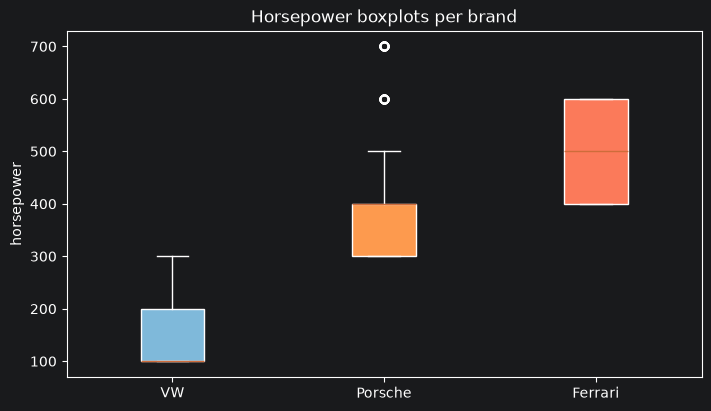

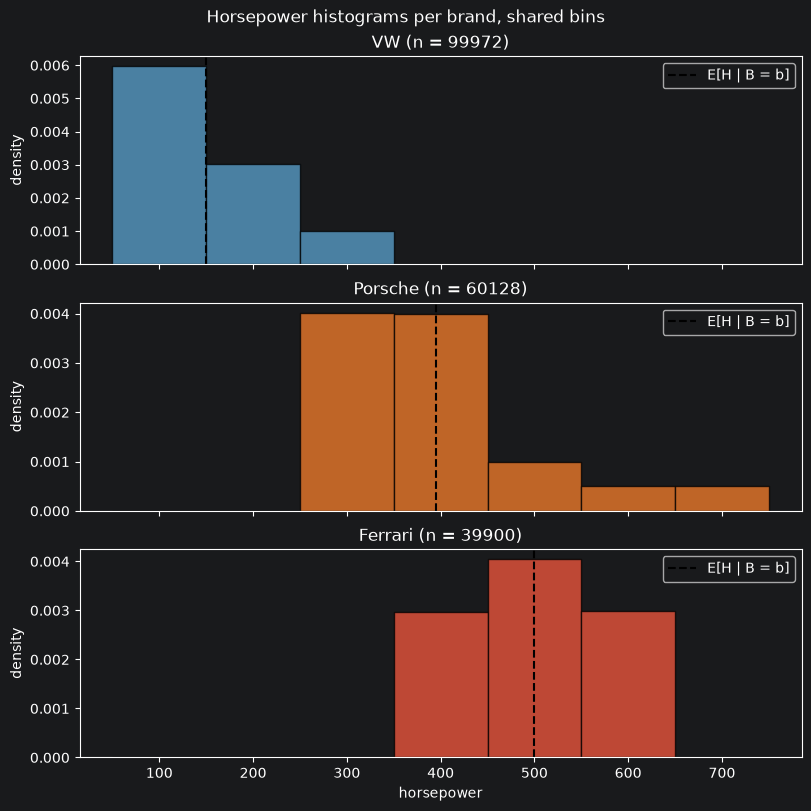

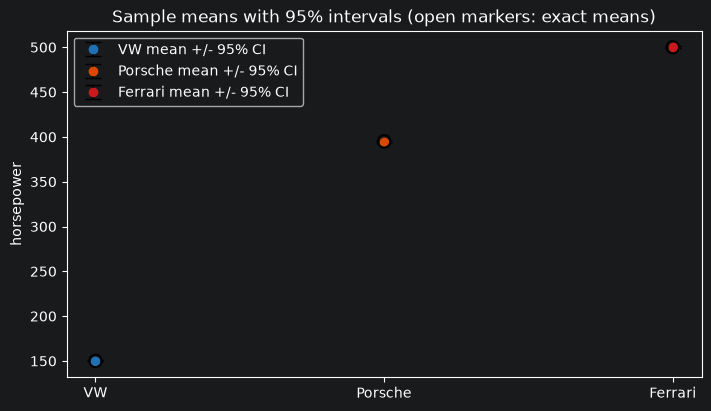

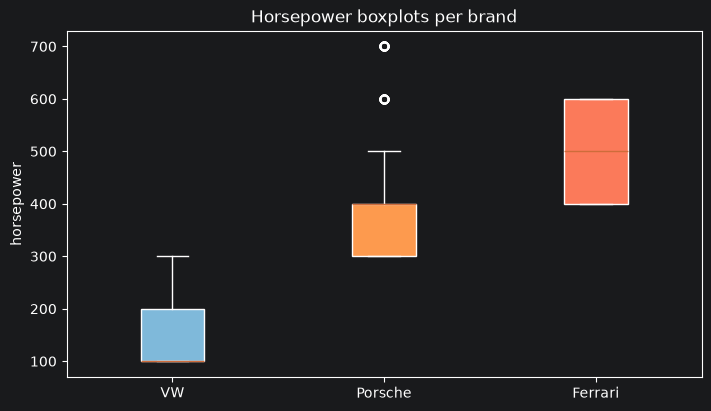

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

brands = ["VW", "Porsche", "Ferrari"]
cmaps = {"VW": "Blues", "Porsche": "Oranges", "Ferrari": "Reds"}
support = np.array([100, 200, 300, 400, 500, 600, 700])
edges = np.concatenate([support - 50, [750]])

# (a) grouped histograms with shared bins plus exact-mean vlines
figure, axes = plt.subplots(3, 1, figsize=(8.0, 8.0), dpi=100, layout="constrained", sharex=True)
for ax, brand in zip(axes, brands, strict=True):
    values = cars[cars["brand"] == brand]["horsepower"].to_numpy(dtype=float)
    color = matplotlib.colormaps[cmaps[brand]](0.55)
    ax.hist(values, bins=edges, density=True, color=color, edgecolor="black", alpha=0.75)
    ax.axvline(conditional_horsepower_mean(brand), color="black", linestyle="--", label="E[H | B = b]")
    ax.set_title(f"{brand} (n = {len(values)})")
    ax.set_ylabel("density")
    ax.legend()
axes[-1].set_xlabel("horsepower")
figure.suptitle("Horsepower histograms per brand, shared bins")
figure
# (b) mean-with-interval panel: 95% whiskers plus exact-mean markers
figure, ax = plt.subplots(figsize=(7.0, 4.0), dpi=100, layout="constrained")
for i, brand in enumerate(brands):
    row = summary.loc[brand]
    color = matplotlib.colormaps[cmaps[brand]](0.75)
    ax.errorbar(i, row["mean"], yerr=1.96 * row["se"], fmt="o", color=color, ecolor="black", capsize=6, label=f"{brand} mean +/- 95% CI")
    ax.scatter([i], [row["E[H | B = b]"]], s=80, facecolors="none", edgecolors="black", linewidths=1.5, zorder=3)
ax.set_xticks(range(len(brands)), brands)
ax.set_ylabel("horsepower")
ax.set_title("Sample means with 95% intervals (open markers: exact means)")
ax.legend()
figure

# (c) boxplots per brand over the same sample
figure, ax = plt.subplots(figsize=(7.0, 4.0), dpi=100, layout="constrained")
data = [cars[cars["brand"] == brand]["horsepower"].to_numpy(dtype=float) for brand in brands]
box = ax.boxplot(data, tick_labels=brands, patch_artist=True)
for patch, brand in zip(box["boxes"], brands, strict=True):
    patch.set_facecolor(matplotlib.colormaps[cmaps[brand]](0.45))
ax.set_ylabel("horsepower")
ax.set_title("Horsepower boxplots per brand")
figure

## References

- Blitzstein, J. K., Hwang, J. (2019): "Introduction to Probability", 2nd ed., Chapman & Hall/CRC, chapters "Inequalities and Limit Theorems" and "Conditional Expectation", https://www.routledge.com/Introduction-to-Probability-Second-Edition/Blitzstein-Hwang/p/book/9781138369917 (free PDF: https://probabilitybook.net/).
- Wasserman, L. (2004): "All of Statistics: A Concise Course in Statistical Inference", Springer Texts in Statistics, chapters "Estimation" and "Convergence of Random Variables", https://doi.org/10.1007/978-0-387-21736-9.
- scipy.stats.rv_discrete, https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_discrete.html.